# Detekce, popis a klasifikace obličeje z RGB obrazu
Druhá část cvičení se zaměří na detekci obličeje pomocí tradičních metod zpracování obrazu.

## Stažení modelů
Natrénované modely tradičními způsoby jsou umístěné ve složce `models`. Jedná se o modely typu: 

* [HaarCascades](https://www.pyimagesearch.com/2021/04/12/opencv-haar-cascades/)
* [Histogram of Orineted Gradients (HOG)](https://courses.fit.cvut.cz/BI-SVZ/showroom/histogram_of_oriented_gradients/index.html)
* [Local Binary Patterns (LBP)](https://www.pyimagesearch.com/2015/12/07/local-binary-patterns-with-python-opencv/)

## Detekce obličeje
Prvním úkolem je ve vstupním obrazu detekovat umístění obličeje nebo obličejů. Jednak nám to umožní vyfiltrovat nedůležité části obrazu před dalším zpracováním a typicky tak zpracování urychlit a zpřesnit, ale především nám to pomůže při výskytu více obličejů v jednom obrázku. 

Jenže, jak na to? Zkusme si představit jak vypadá typický obličej. Oči a obočí jsou tmavší než tváře, stejně tak jsou tmavší než nos. Jenže modelovat explicitně podobu obličeje je poměrně pracné. Především, když můžeme použít hrubou sílu a nechat si vymodelovat typický obličej ne na úrovni pixelů, ale na úrovni rozdílů intenzit vhodně zvolených oblastí napříč rozlišeními.

K tomu je možné použít například Haarovu funkci všemožně naškálovanou a narotovanou jak je podrobněji popsáno v článku Paula Violy a Michaela Jonese: "Rapid Object Detection using a Boosted Cascade of Simple Features" a klasifikátor, který bude detekovat ty oblasti obrázku, které obsahují předučenou kombinaci rozdílů intenzit podle vybraných funkcí.

<img src="images/haar_wavelet.svg" width=40% style="float:left"> <img src="images/haar_application.png" width=40%>
<div style="clear:both"/>

Pro učení klasifikátoru je zapotřebí algoritmu dodat velké množství obrázků obličeje (a obrázků, které obličej neobsahují), na kterých proběhne, zjednodušeně řečeno, určení hodnot všech Haarových funkcí a výběr funkcí (a prahů) vhodných pro rozlišení zda obrázek obsahuje nebo neobsahuje obličej. Tím vznikne model, který je při dostatečných schopnostech generalizace možné následně používat pro detekci i neznámých obličejů. Model zde z dat učit nebudeme, použijeme model již natrénovaný pro detekci obličeje dívajícího se přímo do kamery, který je distribuovaný s OpenCV. Pro jistotu jej ale přikládáme přímo do složky s notebookem.



### Importy knihoven, konfigurací a modelů

In [1]:
import os
import io

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pytesseract

from improutils import *
from collections import OrderedDict

%matplotlib inline
np.set_printoptions(formatter={'float': lambda x: "{0:0.3f}".format(x)})

In [2]:
MAIN_FOLDER = 'models/'
FACE_FRONTAL = MAIN_FOLDER + 'haarcascade_frontalface_default.xml'
EYES_NO_GLASSES = MAIN_FOLDER + 'haarcascade_eye.xml'
EYES_WITH_GLASSES = MAIN_FOLDER + 'haarcascade_eye_tree_eyeglasses.xml'
FACE_FRONTAL_ALT = MAIN_FOLDER + 'lbpcascade_frontalface_improved.xml'
FACE_PROFILE = MAIN_FOLDER + 'lbpcascade_profileface.xml'

### Příprava obrázku a detekce

#### 1) Nasnímejte obrázky obličejů
Využijte jakýkoli známý přístup a nasnímejte obrázky obličeje / obličejů a uložte je do složky `data`. Převeďte do odstínů šedi pro detekci Haarovou kaskádou (popř. dalšími modely).

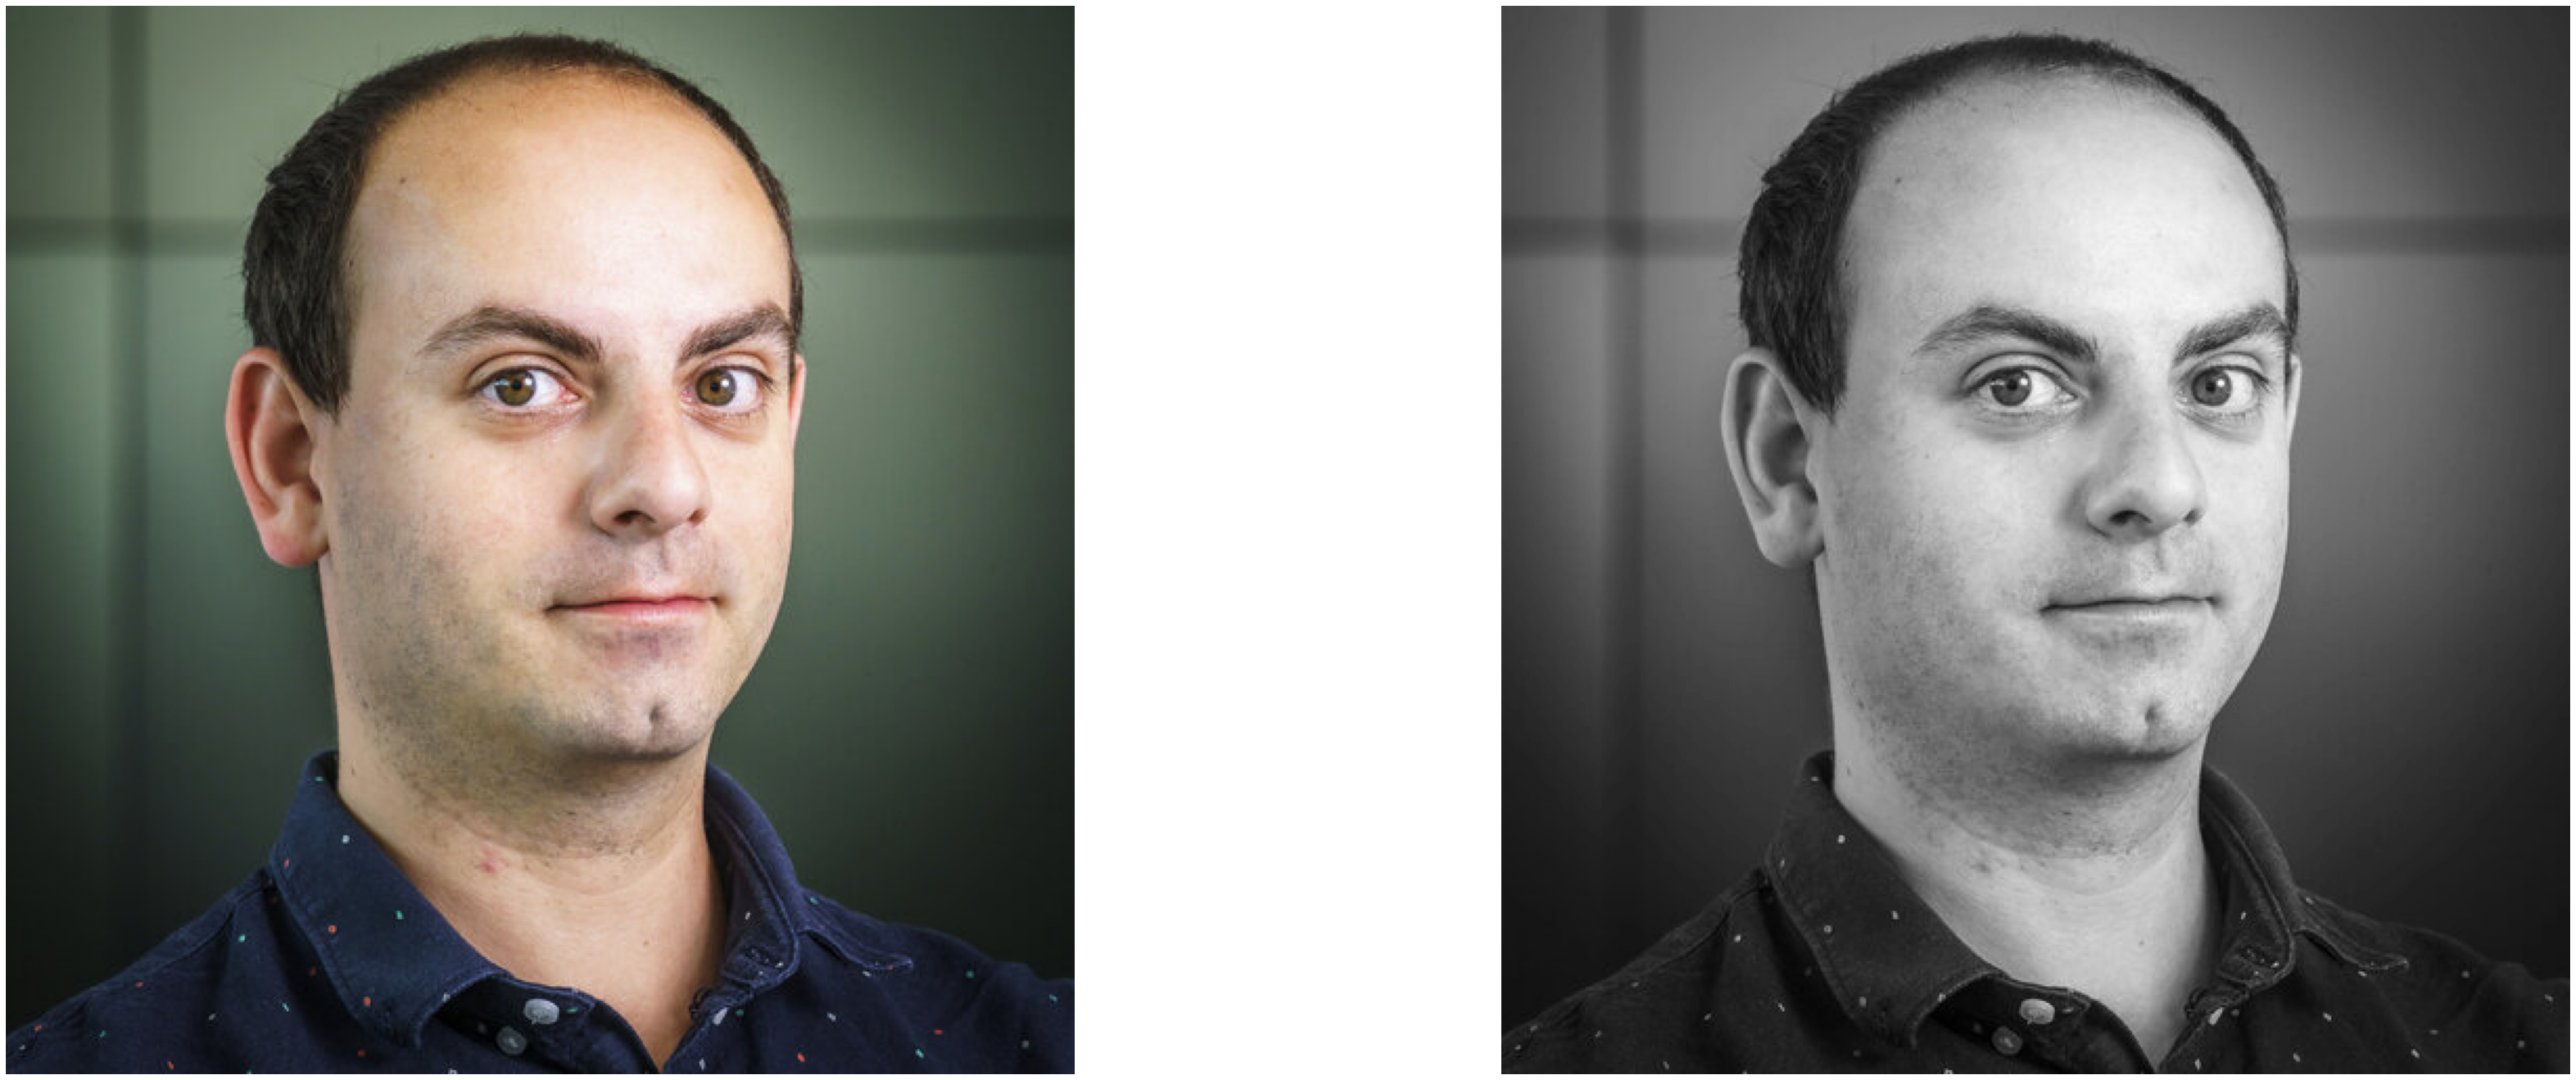

In [3]:
image = load_image("images/knop-dusan.jpeg") ###
image_gray = to_gray(image) ###

plot_images(image, image_gray)

#### 2) Vytvořte potřebné detektory
Vytvořte objekt / objekty detektorů využívající již předučené modely.

In [4]:
face_detector_haar = cv2.CascadeClassifier("models/haarcascade_frontalface_default.xml") ###
eyes_cascade = cv2.CascadeClassifier("models/haarcascade_eye.xml")
### další modely ...
face_detector_ibp = cv2.CascadeClassifier("models/lbpcascade_profileface.xml")
face_detector_ibp_improved = cv2.CascadeClassifier("models/lbpcascade_frontalface_improved.xml")

#### 3) Detekujte obličeje. 
Uvedené parametry funkce `detectMultiScale()` specifikují úroveň škálování a citlivost filtru. Seznamte se s parametry v dokumentaci.

__Vizualizujte__ nalezené obličeje pomocí obdélníků. Každý obličej __jinou barvou__.

In [5]:
def plot_faces(image, image_gray, face_detector):
    faces = face_detector.detectMultiScale(image_gray)
    viz = image.copy()

    for i, (x,y,w,h) in enumerate(faces):
        ptA = (x, y)
        ptB = (x + w, y + h)

        viz = cv2.rectangle(viz, ptA, ptB, color=(0,255,0))
        faceROI = image_gray[y:y+h,x:x+w]

        #-- In each face, detect eyes
        eyes = eyes_cascade.detectMultiScale(faceROI)
        for (x2,y2,w2,h2) in eyes:
            eye_center = (x + x2 + w2//2, y + y2 + h2//2)
            radius = int(round((w2 + h2)*0.25))
            colors = [ (255, 0, 0 ),  (0, 255, 0 ),  (0, 0, 255 ),  (255, 255, 255 )]
            viz = cv2.circle(viz, eye_center, radius, (255, 0, 0 ), 4)
        cv2.imshow('Capture - Face detection', viz)


    plot_images(viz)

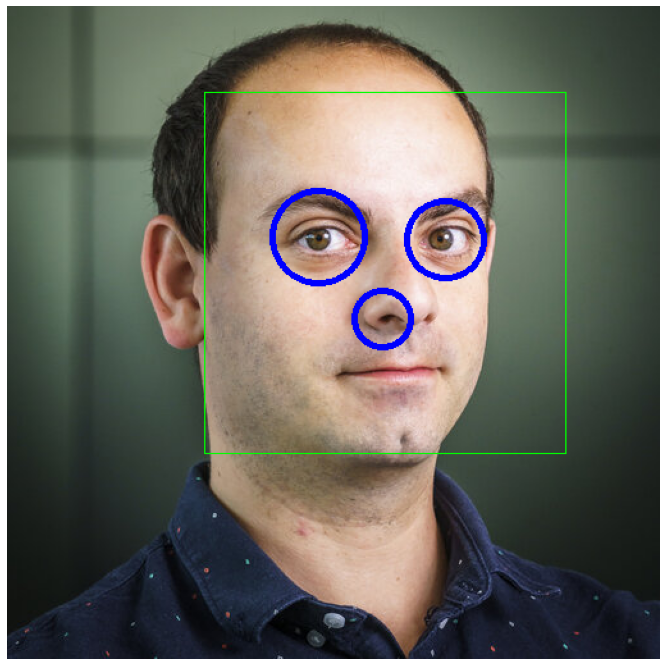

In [6]:
plot_faces(image, image_gray, face_detector_haar)

#### 3) Experimentujte s dalšími modely na datech z internetu
Vyzkoušejte si následující:

1. Limitace detektoru obličejů - srovnání Haar a LBP (natočení hlavy, velikosti obličejů aka rozlišení, ...)
2. Detekce obličeje z profilu
3. Detekce očí s brýlemi a bez

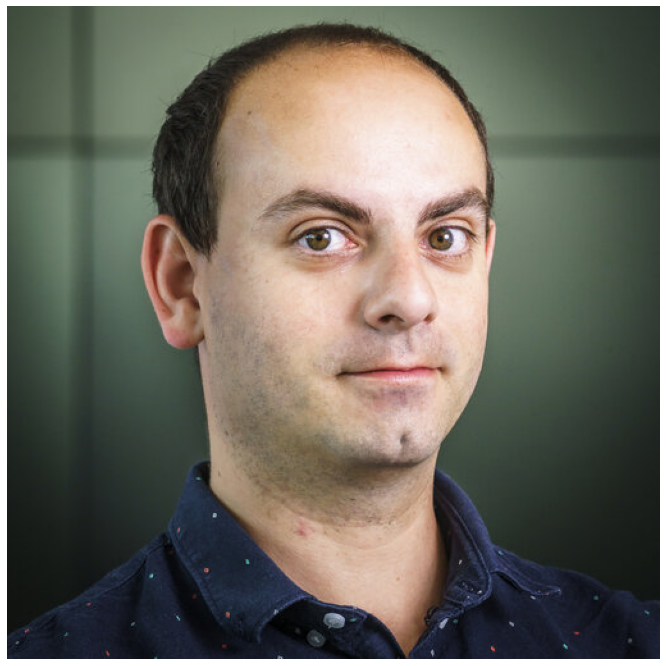

In [7]:
plot_faces(image, image_gray, face_detector_ibp)

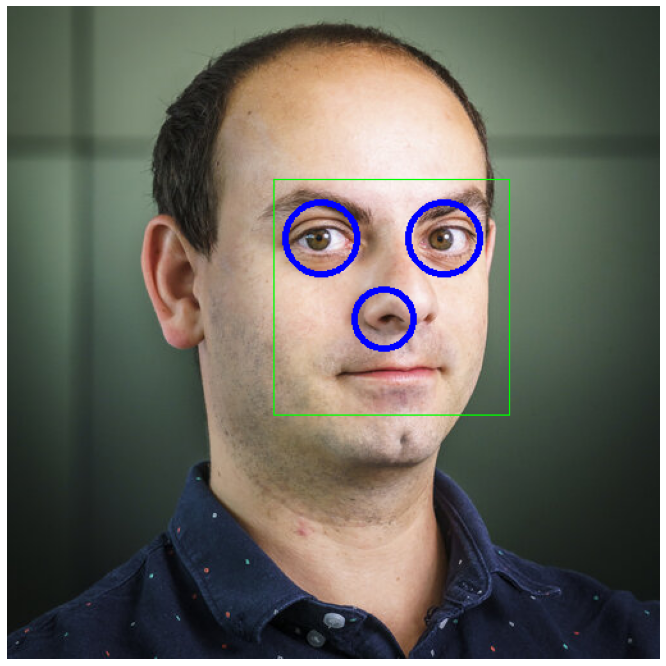

In [8]:
plot_faces(image, image_gray, face_detector_ibp_improved)

In [23]:
eyes_cascade = cv2.CascadeClassifier("models/haarcascade_eye_tree_eyeglasses.xml")
def plot_faces2(image, image_gray, face_detector):
    faces = face_detector.detectMultiScale(image_gray)
    viz = image.copy()

    for i, (x,y,w,h) in enumerate(faces):
        ptA = (x, y)
        ptB = (x + w, y + h)
        colors = [ (255, 0, 0 ),  (0, 255, 0 ),  (0, 0, 255 ),  (255, 255, 255 ), (255, 255, 0 ), (0, 255, 255 ), (255, 0, 255 )]

        viz = cv2.rectangle(viz, ptA, ptB, color=colors[i])
        faceROI = image_gray[y:y+h,x:x+w]

        #-- In each face, detect eyes
        eyes = eyes_cascade.detectMultiScale(faceROI, scaleFactor=1.3, 
                                 minNeighbors=1, 
                                 minSize=(30, 30),
                                 flags=cv2.CASCADE_SCALE_IMAGE)
        for (x2,y2,w2,h2) in eyes:
            eye_center = (x + x2 + w2//2, y + y2 + h2//2)
            radius = int(round((w2 + h2)*0.25))
            viz = cv2.circle(viz, eye_center, radius,(0,255,0), 3)
        cv2.imshow('Capture - Face detection', viz)


    plot_images(viz)

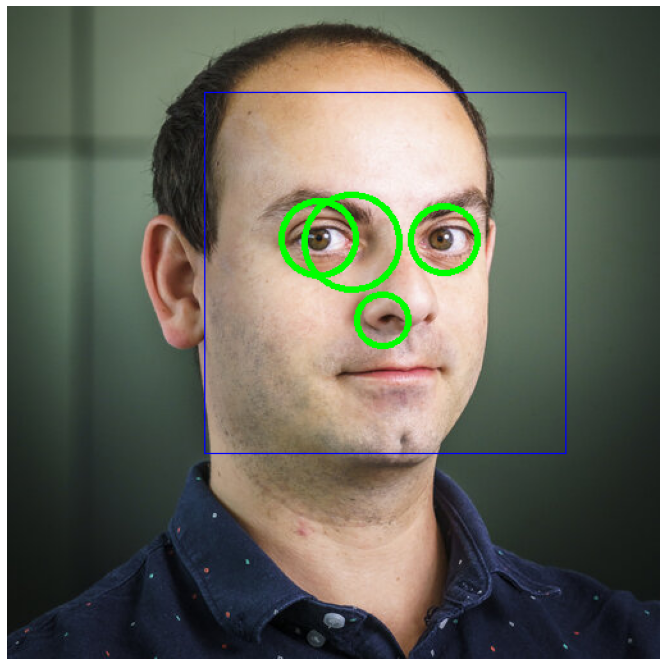

In [24]:
plot_faces2(image, image_gray, face_detector_haar)

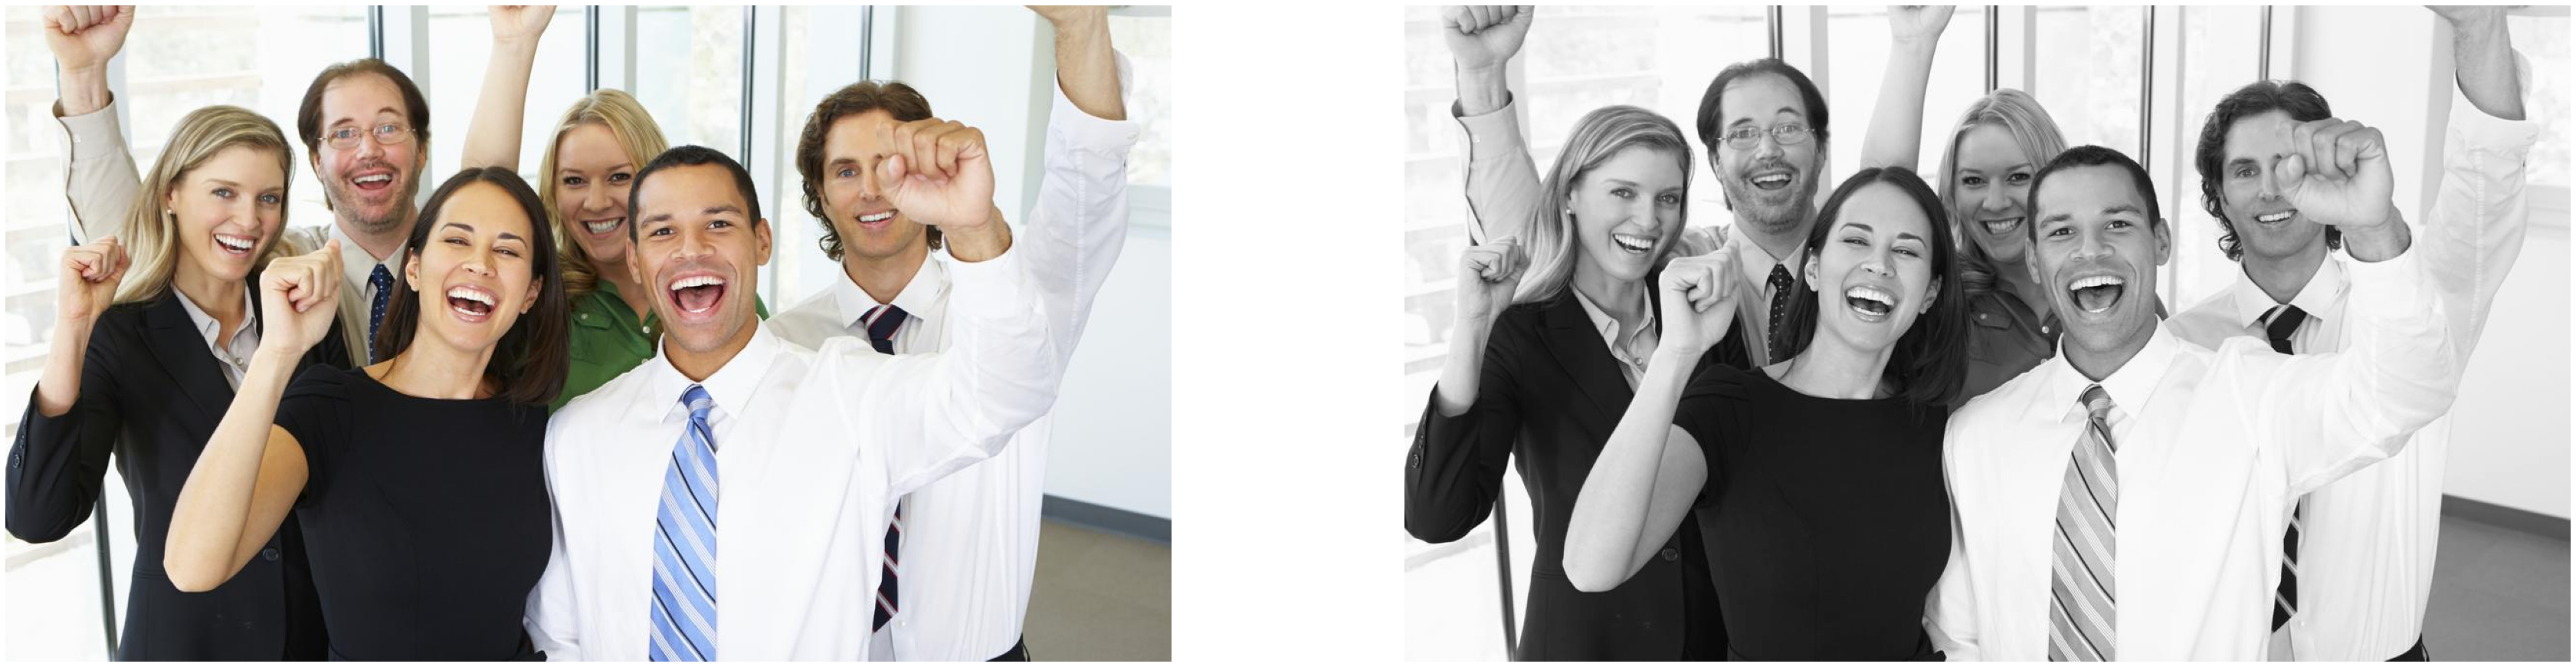

In [15]:
image2 = load_image("images/R.jpg") ###
image_gray2 = to_gray(image2) ###

plot_images(image2, image_gray2)

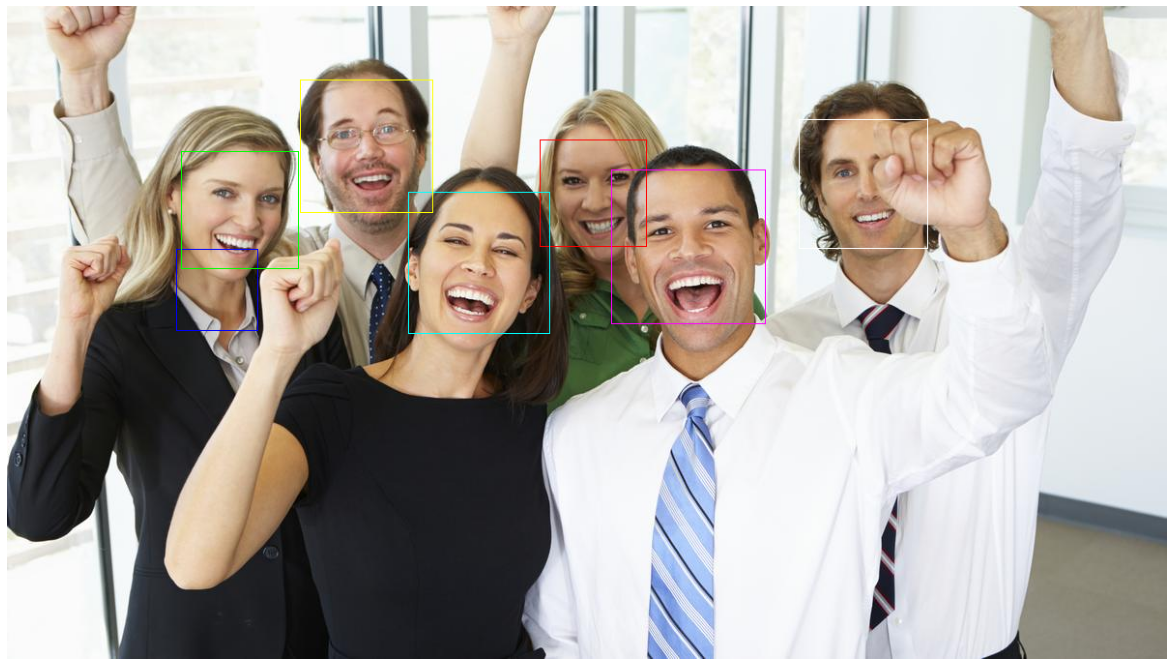

In [16]:
plot_faces2(image2, image_gray2, face_detector_haar)

## Zajímavost na doma - OpenFace
Tento přístup má jistě mnohá úskalí. Pokud se dotyčný nedívá přímo do kamery nebo pokud má výrazně nakloněnou hlavu, detekce ani popis nemusí fungovat správně. Poté je potřeba dělat trochu více magie, kterou nechcete psát stále dokola. A proto vznikla knihovna OpenFace: https://cmusatyalab.github.io/openface/

Doporučuji vyzkoušet.